In [32]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
# Requires: python compute_metrics.py
import warnings
warnings.filterwarnings("ignore", message="Pandas requires version", category=UserWarning)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

df = pd.read_csv("results/metrics.csv")
df["gain_pp"]       = df["snr_pp"]       - df["snr_raw"]
df["gain_denoised"] = df["snr_denoised"] - df["snr_raw"]

with open("results/denoising/splits.json") as f:
    _splits = json.load(f)

# sample_id in metrics.csv is int64 — compare directly to int IDs from splits.json
_split_map = {sid: sname for sname, ids in _splits.items() for sid in ids}
df["split"] = df["sample_id"].map(_split_map).fillna("unknown")

print(f"{len(df)} samples — {df['split'].value_counts().to_dict()}")
print(df[["snr_raw", "snr_pp", "snr_denoised"]].describe().round(2))

# ── Shared plot helpers ──────────────────────────────────────────────────────
_METHODS = ["snr_raw", "snr_pp", "snr_denoised"]
_LABELS  = ["Raw", "Preprocessed", "UNet Denoised"]
_COLORS  = ["#d9534f", "#5bc0de", "#5cb85c"]
_SPLITS  = ["train", "val", "test"]

def _fig_2row():
    fig = plt.figure(figsize=(14, 10))
    gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
    return fig, fig.add_subplot(gs[0, :]), [fig.add_subplot(gs[1, i]) for i in range(3)]

def _boxplot(ax, sub, title):
    bp = ax.boxplot([sub[m].dropna().values for m in _METHODS],
                    tick_labels=_LABELS, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, c in zip(bp["boxes"], _COLORS):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_ylabel("SNR (dB)"); ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

def _histogram(ax, sub, title):
    for m, lbl, c in zip(_METHODS, _LABELS, _COLORS):
        v = sub[m].dropna().values
        if len(v):
            ax.hist(v, bins=15, alpha=0.5, label=f"{lbl} (med={np.median(v):.1f} dB)", color=c)
    ax.set_xlabel("SNR (dB)"); ax.set_ylabel("Count"); ax.set_title(title)
    ax.legend(fontsize=7); ax.grid(axis="y", linestyle="--", alpha=0.5)

def _gain_bars(ax, sub, title):
    x = np.arange(len(sub))
    ax.bar(x - 0.2, sub["gain_pp"].values,       width=0.4, label="PP gain",       color="#5bc0de", alpha=0.8)
    ax.bar(x + 0.2, sub["gain_denoised"].values, width=0.4, label="Denoised gain", color="#5cb85c", alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Sample index"); ax.set_ylabel("ΔSNR vs Raw (dB)"); ax.set_title(title)
    ax.legend(fontsize=7); ax.grid(axis="y", linestyle="--", alpha=0.5)

81 samples — {'train': 48, 'test': 17, 'val': 16}
       snr_raw  snr_pp  snr_denoised
count    77.00   77.00         77.00
mean     -0.00   10.70          7.73
std       0.02    5.83          5.94
min      -0.12   -6.53         -8.27
25%      -0.01    8.95          3.80
50%      -0.00   11.87          8.05
75%       0.00   15.17         11.21
max       0.02   19.68         19.64


/tmp/ipykernel_3019911/1444610308.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


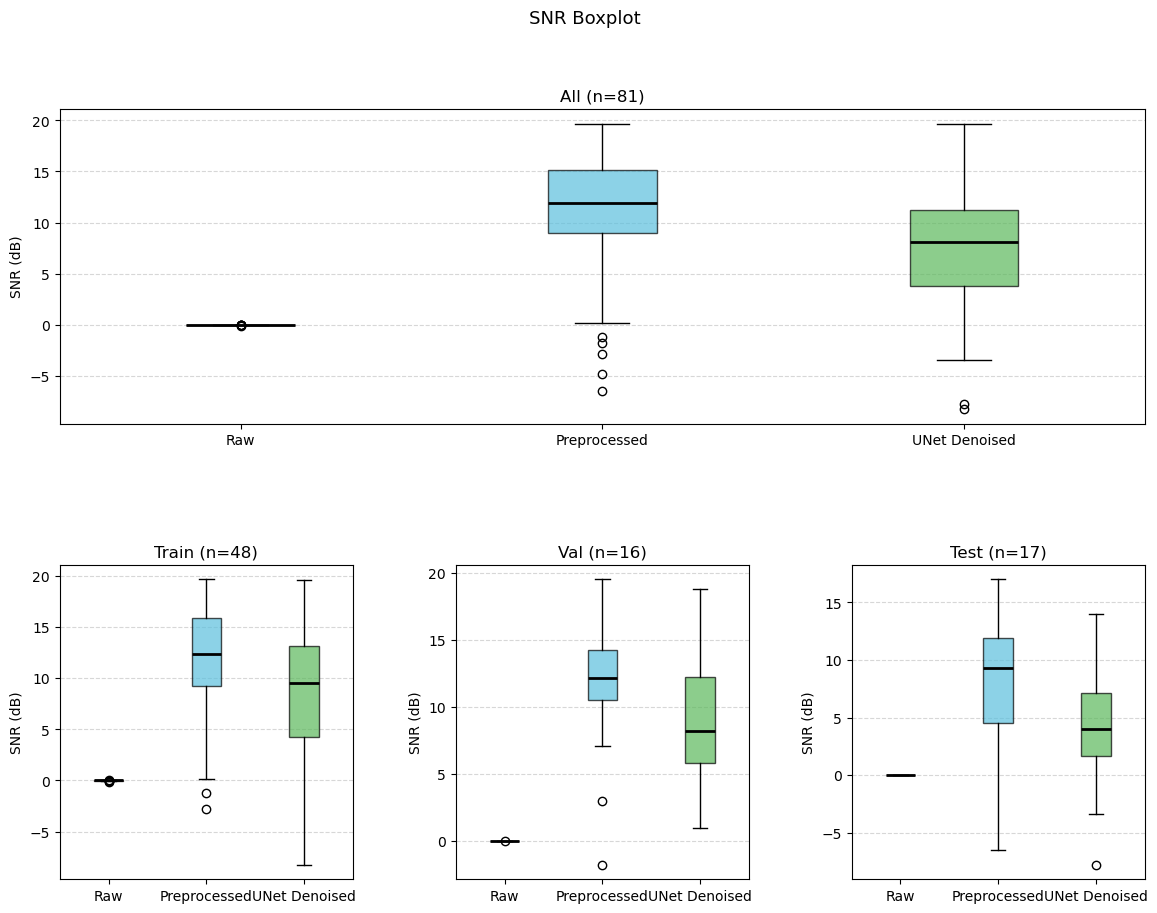

In [35]:
# SNR Boxplot — all (row 1) + train/val/test (row 2)
fig, ax_all, axes_s = _fig_2row()
_boxplot(ax_all, df, f"All (n={len(df)})")
for ax, s in zip(axes_s, _SPLITS):
    sub = df[df["split"] == s]
    _boxplot(ax, sub, f"{s.capitalize()} (n={len(sub)})") if len(sub) else ax.axis("off")
fig.suptitle("SNR Boxplot", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

/tmp/ipykernel_3019911/360308945.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


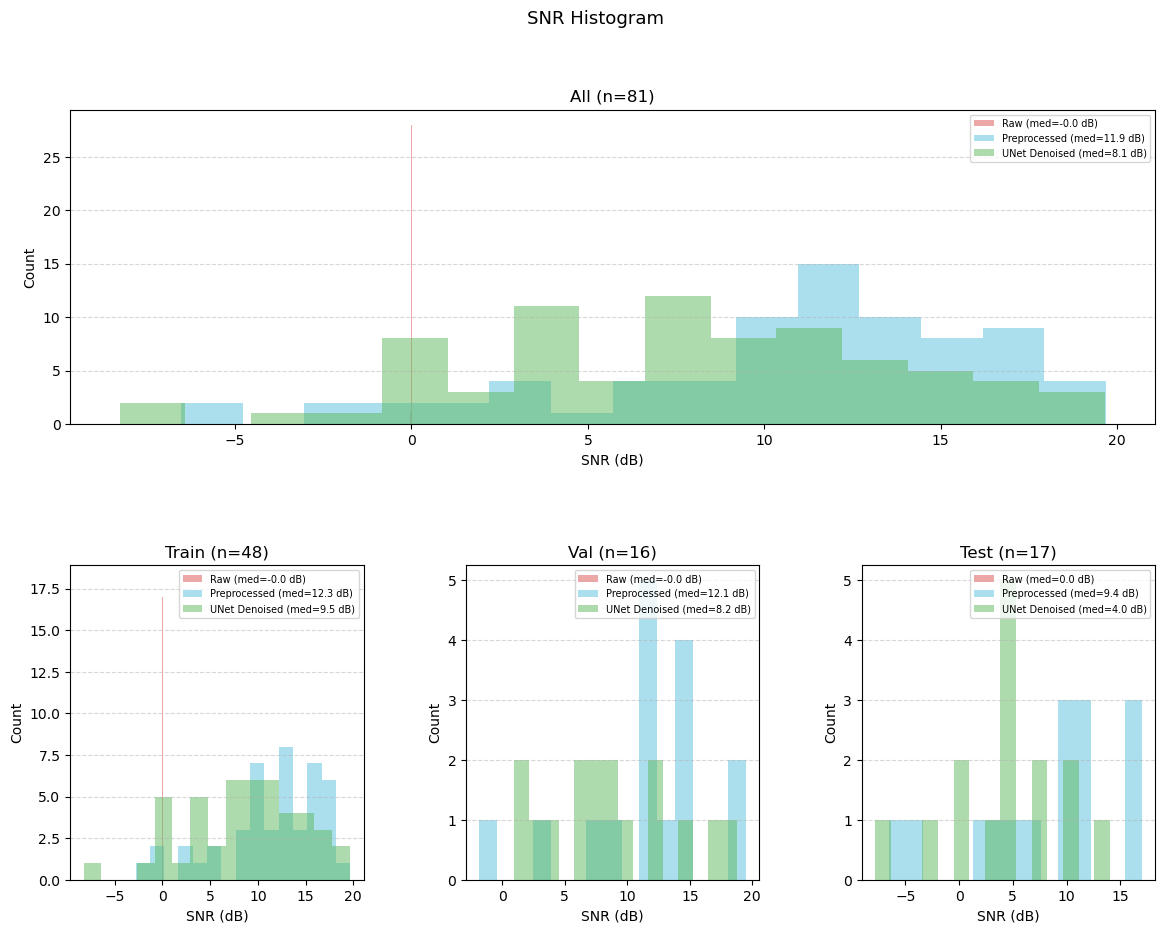

In [36]:
# SNR Histogram — all (row 1) + train/val/test (row 2)
fig, ax_all, axes_s = _fig_2row()
_histogram(ax_all, df, f"All (n={len(df)})")
for ax, s in zip(axes_s, _SPLITS):
    sub = df[df["split"] == s]
    _histogram(ax, sub, f"{s.capitalize()} (n={len(sub)})") if len(sub) else ax.axis("off")
fig.suptitle("SNR Histogram", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

/tmp/ipykernel_3019911/3299153748.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


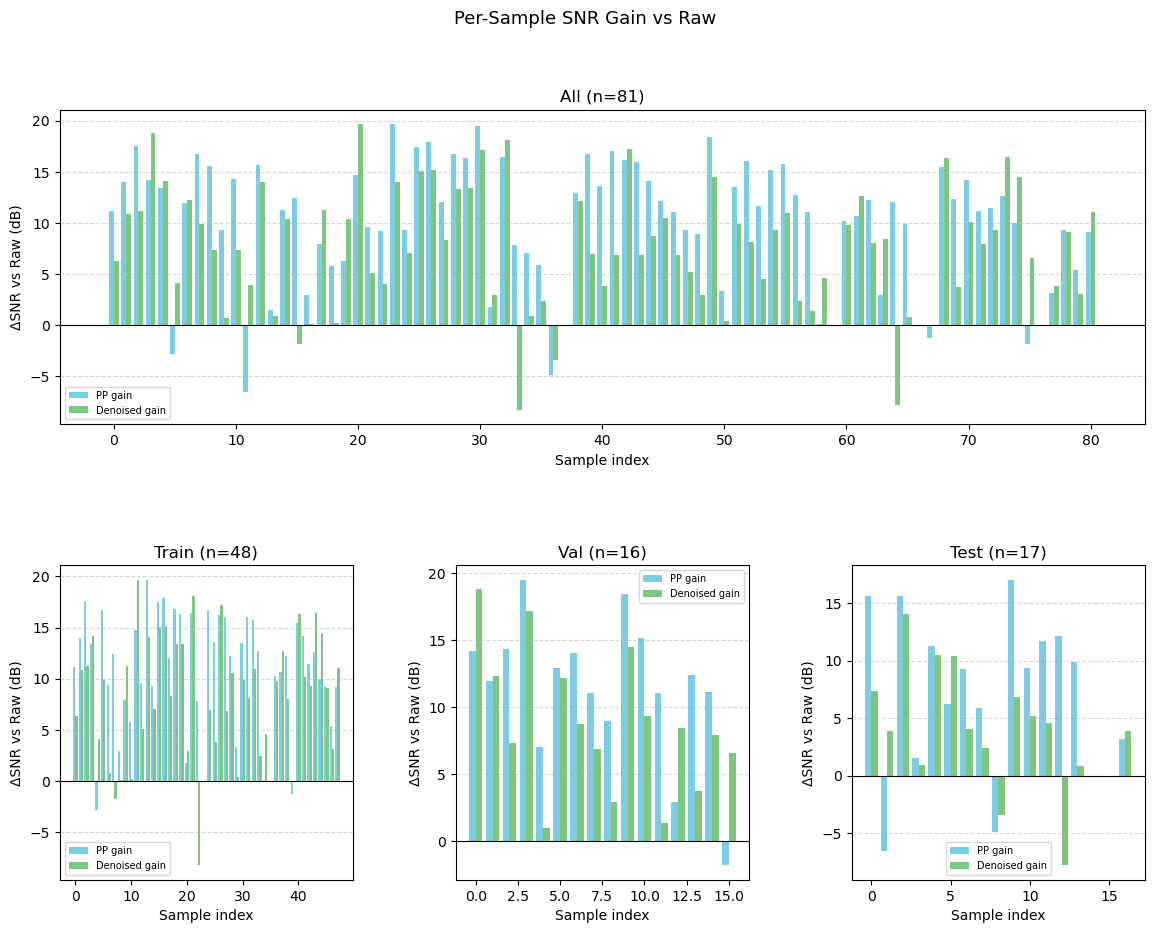

Overall  — median ΔSNR: pp=11.91 dB  denoised=8.05 dB
TRAIN (n=48) — median ΔSNR: pp=12.32 dB  denoised=9.55 dB
VAL   (n=16) — median ΔSNR: pp=12.15 dB  denoised=8.17 dB
TEST  (n=17) — median ΔSNR: pp=9.36 dB  denoised=4.03 dB


In [37]:
# Per-sample SNR gain — all (row 1) + train/val/test (row 2)
fig, ax_all, axes_s = _fig_2row()
_gain_bars(ax_all, df, f"All (n={len(df)})")
for ax, s in zip(axes_s, _SPLITS):
    sub = df[df["split"] == s]
    _gain_bars(ax, sub, f"{s.capitalize()} (n={len(sub)})") if len(sub) else ax.axis("off")
fig.suptitle("Per-Sample SNR Gain vs Raw", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"Overall  — median ΔSNR: pp={df['gain_pp'].median():.2f} dB  denoised={df['gain_denoised'].median():.2f} dB")
for s in _SPLITS:
    sub = df[df["split"] == s]
    if len(sub):
        print(f"{s.upper():5s} (n={len(sub):2d}) — median ΔSNR: pp={sub['gain_pp'].median():.2f} dB  denoised={sub['gain_denoised'].median():.2f} dB")

In [38]:
import os
from Utilities import plot_das_data, compute_snr
from preprocessing import make_preprocess
import yaml, json
from config import load_dataset_config
from DAS import DAS

# Uses ACTIVE_DATASET from config.py — make sure it matches the dataset
# the model in results/denoising/ was trained on.
ds_cfg  = load_dataset_config()
den_cfg = yaml.safe_load(open("configs/denoising.yaml"))

_meta     = DAS(ds_cfg["das_file"]).meta
dx        = ds_cfg.get("dx") or _meta.get("dx")
dt        = ds_cfg.get("dt") or _meta.get("dt")
fs_das    = ds_cfg["fs_das"]
fps_video = ds_cfg["fps_video"]

steps = [(s["name"], {k: v for k, v in s.items() if k != "name"}) for s in den_cfg["steps"]]
pp = make_preprocess(steps=steps, dx=dx, dt=dt)

# Load full labels.csv to get data_path and signal_rects
DATA_DIR  = ds_cfg["data_dir"]
labels_df = pd.read_csv(os.path.join(DATA_DIR, den_cfg["labels_csv"]))
labels_df = labels_df[labels_df["count"] > 0].reset_index(drop=True)
labels_df["split"] = labels_df["sample_id"].map(_split_map).fillna("unknown")

# ── Sample index reference table ─────────────────────────────────────────────
_table = labels_df[["sample_id", "count", "vehicle_type", "split"]].copy()
_table.index.name = "SAMPLE_IDX"
display(_table.style
    .set_caption("Sample index reference — choose SAMPLE_IDX from this table")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]}])
    .map(lambda v: "background-color: #d4edda" if v == "test"
         else ("background-color: #fff3cd" if v == "val" else ""), subset=["split"])
)

,sample_id,count,vehicle_type,split
SAMPLE_IDX,,,,
0,0,4,mixed,train
1,1,2,mixed,train
2,2,2,mixed,train
3,3,2,mixed,val
4,4,2,mixed,train
5,5,1,truck,train
6,6,1,truck,val
7,7,1,pickup,train
8,8,2,mixed,test


/home/chao/Documents/DAS_Preprocessing/Utilities.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


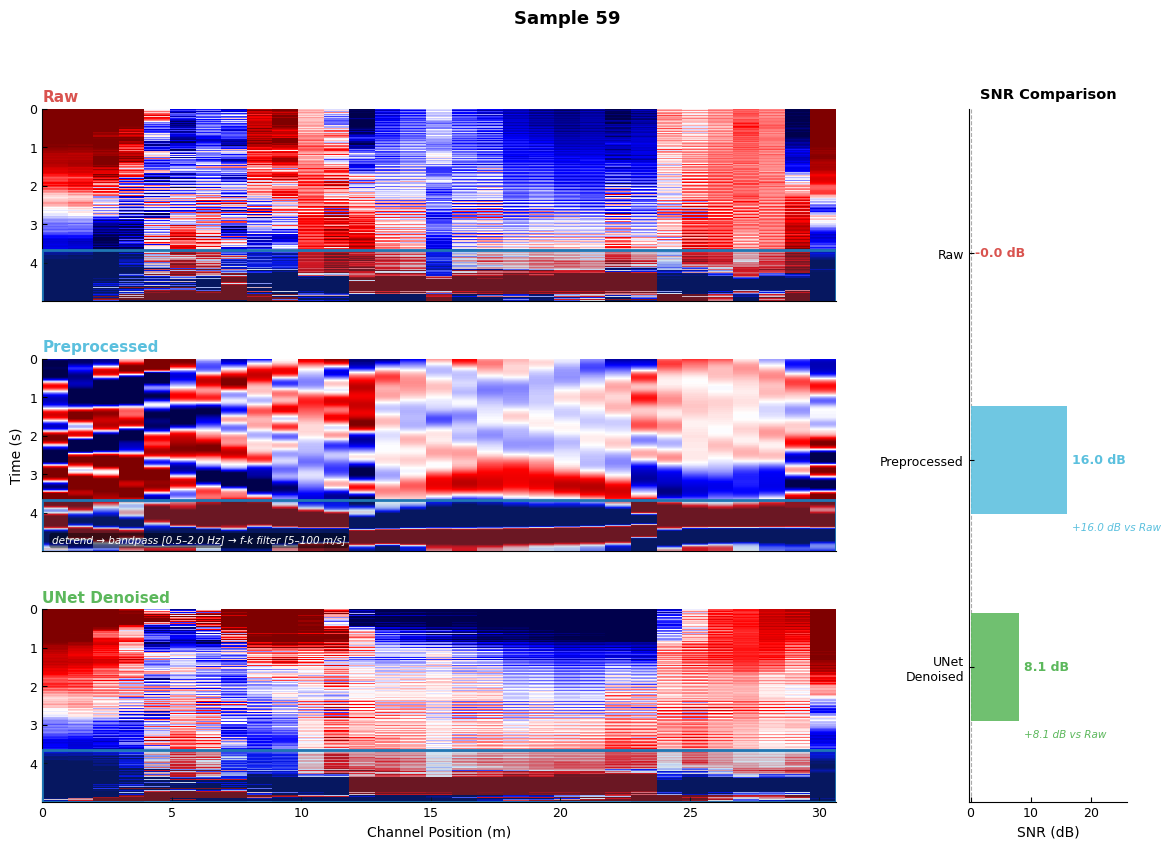

split=train  vehicle=sedan  count=1
SNR  raw=-0.00 dB | pp=16.04 dB | denoised=8.10 dB


In [41]:
SAMPLE_IDX = 52  # index into count>0 sample list — see table above

row             = labels_df.iloc[SAMPLE_IDX]
sid             = row["sample_id"]
rects           = json.loads(row["signal_rects"])
win_start_frame = row["start_frame"]

raw      = np.load(row["data_path"]).astype(np.float32)
clean    = pp(raw, fs_das).astype(np.float32)
denoised = np.load(os.path.join(DATA_DIR, "denoised", f"denoised_sample_{int(sid):06d}.npy")).astype(np.float32)

snr_raw   = compute_snr(raw,      rects, win_start_frame, fps_video, fs_das)
snr_clean = compute_snr(clean,    rects, win_start_frame, fps_video, fs_das)
snr_pred  = compute_snr(denoised, rects, win_start_frame, fps_video, fs_das)

from Utilities import plot_das_comparison

fig, _ = plot_das_comparison(
    raw=raw, clean=clean, denoised=denoised,
    snr_raw=snr_raw, snr_clean=snr_clean, snr_denoised=snr_pred,
    channels=np.arange(raw.shape[0]), dx=dx, dt=dt,
    pp_steps=den_cfg["steps"],
    signal_rects=rects,
    win_start_frame=win_start_frame,
    fps_video=fps_video,
    sample_id=sid,
    show_signal_ticks=False,
    show_signal_shade=False,
    show_rect=True
)
plt.show()
print(f"split={row['split']}  vehicle={row['vehicle_type']}  count={row['count']}")
print(f"SNR  raw={snr_raw:.2f} dB | pp={snr_clean:.2f} dB | denoised={snr_pred:.2f} dB")

In [42]:
rects

[[24187, 24268]]